# Load Dataset

In [ ]:
import tensorflow as tf
import os
import time
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

# Download the classic 'facades' dataset from the official source
dataset_url = "http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/facades.tar.gz"
path_to_zip = tf.keras.utils.get_file('facades.tar.gz', origin=dataset_url, extract=True)
# Correct the PATH calculation to point to the actual dataset root
PATH = os.path.join(path_to_zip, 'facades/')

print(f"Dataset downloaded and extracted to: {PATH}")

2026-04-09 15:14:17.444069: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775747657.658738      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775747657.717497      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775747658.192082      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775747658.192117      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775747658.192119      55 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0
30168306/30168306 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
Dataset downloaded and extracted to: /root/.keras/datasets/facades_extracted/facades/


# Load and split

I0000 00:00:1775747700.149994      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775747700.156182      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


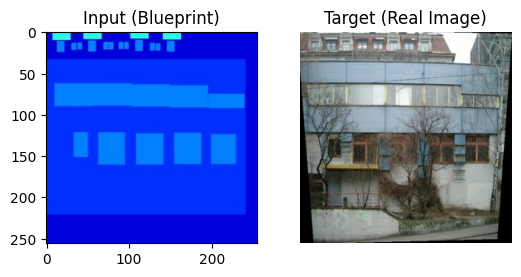

In [ ]:
def load_and_split(image_file):
    # Read and decode the image
    image = tf.io.read_file(image_file)
    image = tf.io.decode_jpeg(image)

    # Split the image in half
    w = tf.shape(image)[1]
    w = w // 2
    real_image = image[:, :w, :]
    input_image = image[:, w:, :]

    # Convert to float32
    input_image = tf.cast(input_image, tf.float32)
    real_image = tf.cast(real_image, tf.float32)

    # Resize to 256x256
    input_image = tf.image.resize(input_image, [256, 256])
    real_image = tf.image.resize(real_image, [256, 256])

    # Normalize the images to [-1, 1]
    input_image = (input_image / 127.5) - 1
    real_image = (real_image / 127.5) - 1

    return input_image, real_image

# Let's test it and visualize one image!
# Dynamically find the first image in the 'train' directory
train_dir = os.path.join(PATH, 'train')
image_files = [f for f in os.listdir(train_dir) if os.path.isfile(os.path.join(train_dir, f)) and f.lower().endswith('.jpg')]

if not image_files:
    raise FileNotFoundError(f"No JPG images found in the training directory: {train_dir}")

first_image_name = image_files[16]
first_image_path = os.path.join(train_dir, first_image_name)

inp, re = load_and_split(first_image_path)

# We multiply by 0.5 and add 0.5 to reverse the [-1, 1] normalization just so we can display it
plt.figure(figsize=(6, 6))
plt.subplot(1, 2, 1)
plt.title('Input (Blueprint)')
plt.imshow(inp * 0.5 + 0.5)
plt.subplot(1, 2, 2)
plt.title('Target (Real Image)')
plt.imshow(re * 0.5 + 0.5)
plt.axis('off')
plt.show()

# Train Dataset

In [ ]:
# Create the training dataset pipeline
train_dataset = tf.data.Dataset.list_files(PATH + 'train/*.jpg')
train_dataset = train_dataset.map(load_and_split, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(400)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
#train_dataset = train_dataset.batch(1) # We use a batch size of 1 as recommended in  the paper

print("Data pipeline ready!")

Data pipeline ready!


In [ ]:
for input_image, real_image in train_dataset.take(1):
    print("Shape of input image:", input_image.shape)
    print("Shape of real image:", real_image.shape)
    print("Data type of input image:", input_image.dtype)
    print("Data type of real image:", real_image.dtype)

# To 'work on' the dataset, you would typically iterate over it in batches
# Let's re-add the batching and then show an example of fetching one batch.
# First, ensure batching is applied:
data = train_dataset.batch(1) # Using batch size of 1 as suggested by the paper

# Get one batch from the batched dataset
for input_batch, real_batch in data.take(1):
    print("\nShape of input batch:", input_batch.shape)
    print("Shape of real batch:", real_batch.shape)


Shape of input image: (256, 256, 3)
Shape of real image: (256, 256, 3)
Data type of input image: <dtype: 'float32'>
Data type of real image: <dtype: 'float32'>

Shape of input batch: (1, 256, 256, 3)
Shape of real batch: (1, 256, 256, 3)


#

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
class CNNblock(keras.Layer):
  def __init__(self,channel,stride):
    super(CNNblock,self).__init__()
    self.conv=layers.Conv2D(channel,kernel_size=4,strides=stride,padding="same")
    self.batchnorm=layers.BatchNormalization()
    self.leakyrelu=layers.LeakyReLU(0.2)
  def call(self,input_tensor,training=False):
    x=self.conv(input_tensor)
    x=self.batchnorm(x,training=training)
    x=self.leakyrelu(x)
    return x

In [ ]:
class CNNblock_drop(keras.Layer):
  def __init__(self,channel):
    super(CNNblock_drop,self).__init__()
    self.conv=layers.Conv2DTranspose(channel,kernel_size=4,strides=2,padding="same")
    self.batchnorm=layers.BatchNormalization()
    self.dropout=layers.Dropout(0.5)
    self.leakyrelu=layers.LeakyReLU(0.2)
  def call(self,input_tensor,training=False):
    x=self.conv(input_tensor)
    x=self.batchnorm(x,training=training)
    x=self.dropout(x,training=training)
    x=self.leakyrelu(x)
    return x

In [ ]:
class CNNblock_trans(keras.Layer):
  def __init__(self,channel):
    super(CNNblock_trans,self).__init__()
    self.conv=layers.Conv2DTranspose(channel,kernel_size=4,strides=2,padding="same")
    self.batchnorm=layers.BatchNormalization()
    self.leakyrelu=layers.LeakyReLU(0.2)
  def call(self,input_tensor,training=False):
    x=self.conv(input_tensor)
    x=self.batchnorm(x,training=training)
    x=self.leakyrelu(x)
    return x

# Generator

In [ ]:
class Generator(keras.Model):

  def __init__(self):
    super(Generator,self).__init__()

    initializer = tf.random_normal_initializer(0., 0.02)
    self.initial_conv = layers.Conv2D(64,kernel_size=4,strides=2,padding="same",kernel_initializer=initializer)
    self.initial_leaky_relu =layers.LeakyReLU(0.2)

    self.cnn_block_128 = CNNblock(128,2)
    self.cnn_block_256 = CNNblock(256,2)
    self.cnn_block_512_1 = CNNblock(512,2)
    self.cnn_block_512_2 = CNNblock(512,2)
    self.cnn_block_512_3 = CNNblock(512,2)
    self.cnn_block_512_4 = CNNblock(512,2)

    self.bottleneck_conv = layers.Conv2D(512,kernel_size=4,strides=2,padding="same")
    self.bottleneck_leaky_relu =layers.LeakyReLU(0.2)

    self.cnn_block_drop_512_1 = CNNblock_drop(512)
    self.cnn_block_drop_512_2 = CNNblock_drop(512)
    self.cnn_block_drop_512_3 = CNNblock_drop(512)

    self.cnn_block_trans_512 = CNNblock_trans(512)
    self.cnn_block_trans_256 = CNNblock_trans(256)
    self.cnn_block_trans_128 = CNNblock_trans(128)
    self.cnn_block_trans_64 = CNNblock_trans(64)

    self.final_conv_transpose = layers.Conv2DTranspose(3,kernel_size=4,strides=2,padding="same")
    self.final_activation = layers.Activation("tanh")

  def call(self, input_tensor,training=False):

    e1_conv_out = self.initial_conv(input_tensor)
    e1 = self.initial_leaky_relu(e1_conv_out)

    e2 = self.cnn_block_128(e1,training=training)
    e3 = self.cnn_block_256(e2,training=training)

    e4 = self.cnn_block_512_1(e3,training=training)
    e5 = self.cnn_block_512_2(e4,training=training)
    e6 = self.cnn_block_512_3(e5,training=training)
    e7 = self.cnn_block_512_4(e6,training=training)


    bottleneck_conv_out = self.bottleneck_conv(e7)
    bottleneck_out = self.bottleneck_leaky_relu(bottleneck_conv_out)


    d1 = self.cnn_block_drop_512_1(bottleneck_out,training=training)
    d1 = d1 + e7

    d2 = self.cnn_block_drop_512_2(d1,training=training)
    d2 = d2 + e6

    d3 = self.cnn_block_drop_512_3(d2,training=training)
    d3 = d3 + e5

    d4 = self.cnn_block_trans_512(d3,training=training)
    d4 = d4 + e4

    d5 = self.cnn_block_trans_256(d4,training=training)
    d5 = d5 + e3

    d6 = self.cnn_block_trans_128(d5,training=training)
    d6 = d6 + e2

    d7 = self.cnn_block_trans_64(d6,training=training)
    d7 = d7 + e1

    final_conv_transpose_out = self.final_conv_transpose(d7)
    output = self.final_activation(final_conv_transpose_out)

    return output

In [ ]:
Generator = Generator()
input=tf.random.normal(shape=(1,256,256,3))
output=Generator(input)
Generator.summary()

I0000 00:00:1775747703.976576      55 cuda_dnn.cc:529] Loaded cuDNN version 91002


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (1, 128, 128, 64)      │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock (CNNblock)            │ ?                      │       131,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_1 (CNNblock)          │ ?                      │       525,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_2 (CNNblock)          │ ?                      │     2,099,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_3 (CNNblock)          │ ?                      │     4,196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_4 (CNNblock)          │ ?                      │     4,196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_5 (CNNblock)          │ ?                      │     4,196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (1, 1, 1, 512)         │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_drop (CNNblock_drop)  │ ?                      │     4,196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_drop_1                │ ?                      │     4,196,864 │
│ (CNNblock_drop)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_drop_2                │ ?                      │     4,196,864 │
│ (CNNblock_drop)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_trans                 │ ?                      │     4,196,864 │
│ (CNNblock_trans)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_trans_1               │ ?                      │     2,098,432 │
│ (CNNblock_trans)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_trans_2               │ ?                      │       524,928 │
│ (CNNblock_trans)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_trans_3               │ ?                      │       131,392 │
│ (CNNblock_trans)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (1, 256, 256, 3)       │         3,075 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ ?                      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,090,819 (149.12 MB)

 Trainable params: 39,080,963 (149.08 MB)

 Non-trainable params: 9,856 (38.50 KB)

# Discriminator

In [ ]:
class Discriminator(keras.Model):
  def __init__(self):
    super(Discriminator,self).__init__()
    initializer = tf.random_normal_initializer(0., 0.02)
    self.initial_conv=layers.Conv2D(64,kernel_size=4,strides=2,padding="same",kernel_initializer=initializer)
    self.initial_leaky_relu=layers.LeakyReLU(0.2)
    self.lay1=CNNblock(128,2)
    self.lay2=CNNblock(256,2)
    self.lay3=CNNblock(512,2)
    self.out_lay=layers.Conv2D(1,kernel_size=4,strides=1,padding="valid")
  def call(self,input,training=False):
    x=self.initial_conv(input)
    x=self.initial_leaky_relu(x)
    x=self.lay1(x,training=training)
    x=self.lay2(x,training=training)
    x=self.lay3(x,training=training)
    x=self.out_lay(x)
    return x

In [ ]:
Discriminator=Discriminator()
input=tf.random.normal(shape=(1,256,256,6))
output=Discriminator(input)
Discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (1, 128, 128, 64)      │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_6 (CNNblock)          │ ?                      │       131,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_7 (CNNblock)          │ ?                      │       525,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_8 (CNNblock)          │ ?                      │     2,099,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (1, 13, 13, 1)         │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,771,393 (10.57 MB)

 Trainable params: 2,769,601 (10.57 MB)

 Non-trainable params: 1,792 (7.00 KB)

# Loss

In [ ]:
cross_entropy=keras.losses.BinaryCrossentropy(from_logits=True)

In [ ]:
def Discriminator_loss(real_output,fake_output):
  real_loss=cross_entropy(tf.ones_like(real_output)*0.9,real_output)
  fake_loss=cross_entropy(tf.zeros_like(fake_output),fake_output)
  total_loss=fake_loss+real_loss
  return total_loss

In [ ]:
def Generator_loss(fake_output,fake,real):
  c=100
  loss=cross_entropy(tf.ones_like(fake_output),fake_output)+c*tf.reduce_mean(tf.abs(real-fake))
  return loss



# Optimizers

In [ ]:

optimizer1=tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5,
    beta_2=0.999
)

optimizer2=tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5,
    beta_2=0.999
)

# Concate 2 tensors

In [ ]:
from tensorflow.keras.layers import Concatenate
def concat(image,label):
  return tf.concat([image, label], axis=-1)

# Training Loop

In [ ]:
@tf.function
def training_loop(image_x,image_y):


  with tf.GradientTape() as gen_tape,tf.GradientTape() as disc_tape:

    image_gen=Generator(image_x,training=True)
    real_image=concat(image_x,image_y)
    fake_image=concat(image_x,image_gen)
    real_output=Discriminator(real_image,training=True)
    fake_output=Discriminator(tf.stop_gradient(fake_image),training=True)

    disc_loss=Discriminator_loss(real_output,fake_output)

    fake_output2=Discriminator(fake_image,training=True)
    gen_loss=Generator_loss(fake_output2,image_gen,image_y)

  disc_gradients=disc_tape.gradient(disc_loss,Discriminator.trainable_variables)
  gen_gradients=gen_tape.gradient(gen_loss,Generator.trainable_variables)

  optimizer1.apply_gradients(zip(disc_gradients,Discriminator.trainable_variables))
  optimizer2.apply_gradients(zip(gen_gradients,Generator.trainable_variables))

  return gen_loss, disc_loss

# Load TestData

In [ ]:
test_dataset = tf.data.Dataset.list_files(PATH + 'test/*.jpg')
test_dataset = test_dataset.map(load_and_split, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(1) # Use batch size of 1 for consistency

print("Test data pipeline ready!")

Test data pipeline ready!


# Train Model

In [ ]:
for example_x, example_y in test_dataset.take(3):
    fixed_x, fixed_y = example_x, example_y


def train(epochs):
    steps_per_epoch = tf.data.experimental.cardinality(data).numpy()

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        # Initialize Keras progress bar
        progbar = tf.keras.utils.Progbar(steps_per_epoch)

        for step, (image_x, image_y) in enumerate(data):
            g_loss, d_loss = training_loop(image_x, image_y)

            # Update bar with current losses
            progbar.update(step + 1, values=[("gen_loss", g_loss), ("disc_loss", d_loss)])

        # Every epoch (or every 5), show the model's progress
        if (epoch + 1) % 5 == 0:
            generate_and_plot(fixed_x, fixed_y)

from IPython import display # Add this import at the top

def generate_and_plot(test_input, target):
    prediction = Generator(test_input, training=False)

    # This line clears the previous plots so they don't stack vertically
    display.clear_output(wait=True)

    plt.figure(figsize=(12, 4))
    display_list = [test_input[0], target[0], prediction[0]]
    titles = ['Input', 'Target', 'Generated']

    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.title(titles[i])
        plt.imshow(display_list[i] * 0.5 + 0.5)
        plt.axis('off')

    plt.show()
    # Adding a small pause helps Kaggle's renderer
    plt.pause(0.1)

# Generate & save Generator

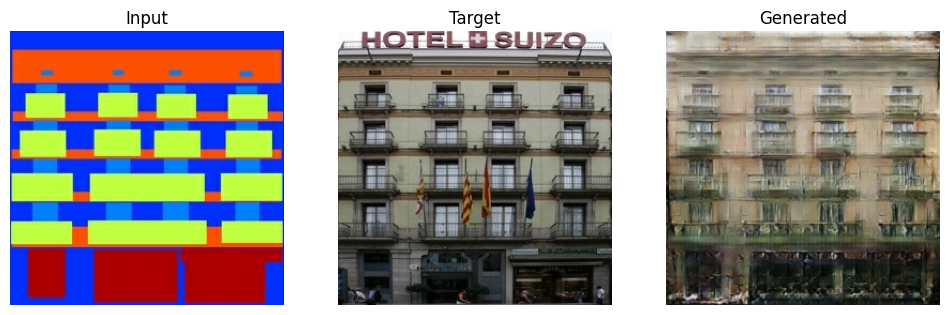

In [ ]:
train(100)
Generator.save("Generator.keras")

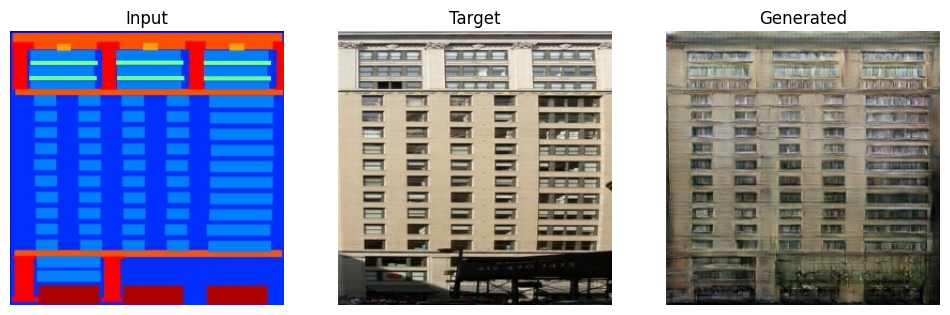

In [ ]:
for example_x, example_y in test_dataset.take(10):
    fixed_x, fixed_y = example_x, example_y
    generate_and_plot(fixed_x, fixed_y)